In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
url = "https://data.cityofnewyork.us/resource/kh3d-xhq7.csv?$limit=5000"

df = pd.read_csv(url)

print("Dataset loaded!")
print("Rows:", len(df))
print("Columns:", len(df.columns))

df.head()

Dataset loaded!
Rows: 66
Columns: 16


,name,address,phone,latitude,longitude,hours_can_be_viewed_via_branch_url_,city,postcode,borough,community_board,community_council,census_tract,bin,bbl,nta,point
0,Arverne,312 Beach 54 Street,(718) 634-4784,40.59,-73.78,https://www.queenslibrary.org/about-us/locatio...,Arverne,11692,QUEENS,414,31,97204,4301922,4158900018,QN1402,POINT (-73.78 40.59)
1,Bayside,214-20 Northern Boulevard,(718) 229-1834,40.76,-73.77,https://www.queenslibrary.org/about-us/locatio...,Bayside,11361,QUEENS,411,19,1471,4157389,4073330215,QN1102,POINT (-73.77 40.76)
2,Cambria Heights,218-13 Linden Boulevard,(718) 528-3535,40.70,-73.74,https://www.queenslibrary.org/about-us/locatio...,Cambria Heights,11411,QUEENS,413,27,598,4536041,4113190001,QN1304,POINT (-73.74 40.7)
3,South Hollis,204-01 Hollis Avenue,(718) 465-6779,40.71,-73.75,https://www.queenslibrary.org/about-us/locatio...,South Hollis,11412,QUEENS,412,27,508,4442263,4109070030,QN1206,POINT (-73.75 40.71)
4,Ozone Park,92-24 Rockaway Boulevard,(718) 845-3127,40.68,-73.85,https://www.queenslibrary.org/about-us/locatio...,Ozone Park,11417,QUEENS,410,32,54,4189526,4091130030,QN1002,POINT (-73.85 40.68)


In [3]:
# View all column names
print("COLUMN NAMES:")
for column in df.columns:
    print(column)

print("\nMISSING VALUES:")
print(df.isnull().sum())

print("\nDUPLICATE ROWS:")
print(df.duplicated().sum())

COLUMN NAMES:
name
address
phone
latitude
longitude
hours_can_be_viewed_via_branch_url_
city
postcode
borough
community_board
community_council
census_tract
bin
bbl
nta
point

MISSING VALUES:
name                                   0
address                                0
phone                                  0
latitude                               0
longitude                              0
hours_can_be_viewed_via_branch_url_    0
city                                   0
postcode                               0
borough                                0
community_board                        0
community_council                      0
census_tract                           0
bin                                    0
bbl                                    0
nta                                    0
point                                  0
dtype: int64

DUPLICATE ROWS:
0


In [4]:
# Create a copy for cleaning
library = df.copy()

# Rename columns to make them easier to understand
library = library.rename(columns={
    "name": "Branch_Name",
    "address": "Address",
    "phone": "Phone",
    "latitude": "Latitude",
    "longitude": "Longitude",
    "city": "Neighborhood",
    "postcode": "ZIP_Code",
    "borough": "Borough",
    "community_board": "Community_Board",
    "community_council": "Council_District",
    "census_tract": "Census_Tract",
    "nta": "NTA"
})

# Make latitude and longitude numeric
library["Latitude"] = pd.to_numeric(library["Latitude"], errors="coerce")
library["Longitude"] = pd.to_numeric(library["Longitude"], errors="coerce")

# Treat ZIP codes and geographic district IDs as categories/text
library["ZIP_Code"] = library["ZIP_Code"].astype(str)
library["Community_Board"] = library["Community_Board"].astype(str)
library["Council_District"] = library["Council_District"].astype(str)

print("Cleaned dataset shape:", library.shape)

library.head()

Cleaned dataset shape: (66, 16)


,Branch_Name,Address,Phone,Latitude,Longitude,hours_can_be_viewed_via_branch_url_,Neighborhood,ZIP_Code,Borough,Community_Board,Council_District,Census_Tract,bin,bbl,NTA,point
0,Arverne,312 Beach 54 Street,(718) 634-4784,40.59,-73.78,https://www.queenslibrary.org/about-us/locatio...,Arverne,11692,QUEENS,414,31,97204,4301922,4158900018,QN1402,POINT (-73.78 40.59)
1,Bayside,214-20 Northern Boulevard,(718) 229-1834,40.76,-73.77,https://www.queenslibrary.org/about-us/locatio...,Bayside,11361,QUEENS,411,19,1471,4157389,4073330215,QN1102,POINT (-73.77 40.76)
2,Cambria Heights,218-13 Linden Boulevard,(718) 528-3535,40.70,-73.74,https://www.queenslibrary.org/about-us/locatio...,Cambria Heights,11411,QUEENS,413,27,598,4536041,4113190001,QN1304,POINT (-73.74 40.7)
3,South Hollis,204-01 Hollis Avenue,(718) 465-6779,40.71,-73.75,https://www.queenslibrary.org/about-us/locatio...,South Hollis,11412,QUEENS,412,27,508,4442263,4109070030,QN1206,POINT (-73.75 40.71)
4,Ozone Park,92-24 Rockaway Boulevard,(718) 845-3127,40.68,-73.85,https://www.queenslibrary.org/about-us/locatio...,Ozone Park,11417,QUEENS,410,32,54,4189526,4091130030,QN1002,POINT (-73.85 40.68)


In [5]:
total_branches = library["Branch_Name"].nunique()
total_zip_codes = library["ZIP_Code"].nunique()
total_community_boards = library["Community_Board"].nunique()
total_neighborhoods = library["Neighborhood"].nunique()

print("QUEENS PUBLIC LIBRARY NETWORK")
print("--------------------------------")
print("Library Branches:", total_branches)
print("ZIP Codes Represented:", total_zip_codes)
print("Community Boards Represented:", total_community_boards)
print("Neighborhoods Represented:", total_neighborhoods)

QUEENS PUBLIC LIBRARY NETWORK
--------------------------------
Library Branches: 66
ZIP Codes Represented: 53
Community Boards Represented: 14
Neighborhoods Represented: 41


In [6]:
# Count library branches by Community Board
branches_by_board = (
    library.groupby("Community_Board")
    .size()
    .reset_index(name="Number_of_Branches")
    .sort_values("Number_of_Branches", ascending=False)
)

branches_by_board

,Community_Board,Number_of_Branches
6,407,8
0,401,6
11,412,6
12,413,6
7,408,6
13,414,6
10,411,5
1,402,4
4,405,4
2,403,4


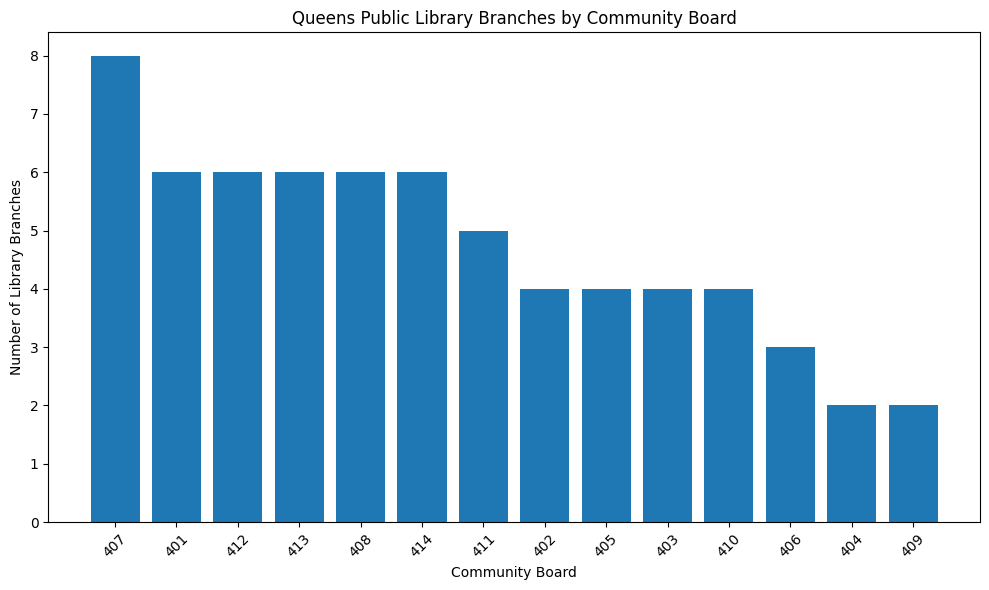

In [7]:
# Visualize branch distribution by Community Board
plt.figure(figsize=(10, 6))

plt.bar(
    branches_by_board["Community_Board"],
    branches_by_board["Number_of_Branches"]
)

plt.title("Queens Public Library Branches by Community Board")
plt.xlabel("Community Board")
plt.ylabel("Number of Library Branches")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [8]:
# Count branches by neighborhood
branches_by_neighborhood = (
    library.groupby("Neighborhood")
    .size()
    .reset_index(name="Number_of_Branches")
    .sort_values("Number_of_Branches", ascending=False)
)

branches_by_neighborhood.head(10)

,Neighborhood,Number_of_Branches
12,Flushing,9
24,Long Island City,6
21,Jamaica,4
8,Corona,3
1,Astoria,3
11,Far Rockaway,2
2,Bayside,2
23,Little Neck,2
13,Forest Hills,2
30,Richmond Hill,2


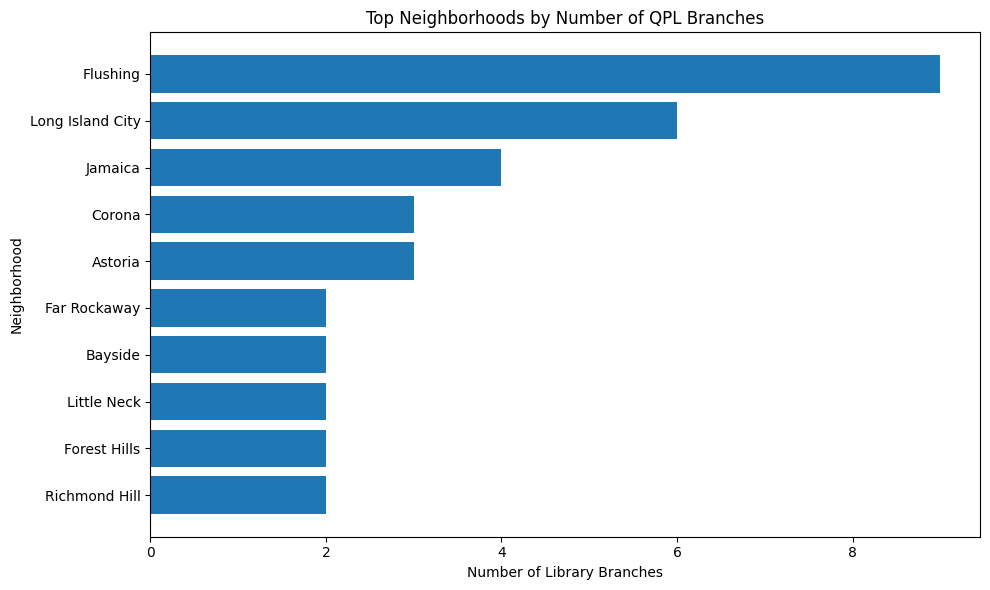

In [9]:
top_neighborhoods = branches_by_neighborhood.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_neighborhoods["Neighborhood"],
    top_neighborhoods["Number_of_Branches"]
)

plt.title("Top Neighborhoods by Number of QPL Branches")
plt.xlabel("Number of Library Branches")
plt.ylabel("Neighborhood")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [10]:
print("LIBRARY NETWORK SUMMARY")
print("-----------------------")

print(f"QPL locations analyzed: {total_branches}")
print(f"Neighborhoods represented: {total_neighborhoods}")
print(f"ZIP codes represented: {total_zip_codes}")
print(f"Community boards represented: {total_community_boards}")

print("\nCommunity Boards with the most library locations:")
print(branches_by_board.head())

print("\nNeighborhoods with the most library locations:")
print(branches_by_neighborhood.head())

LIBRARY NETWORK SUMMARY
-----------------------
QPL locations analyzed: 66
Neighborhoods represented: 41
ZIP codes represented: 53
Community boards represented: 14

Community Boards with the most library locations:
   Community_Board  Number_of_Branches
6              407                   8
0              401                   6
11             412                   6
12             413                   6
7              408                   6

Neighborhoods with the most library locations:
        Neighborhood  Number_of_Branches
12          Flushing                   9
24  Long Island City                   6
21           Jamaica                   4
8             Corona                   3
1            Astoria                   3


In [13]:
from google.colab import files

# Save cleaned data as CSV
library.to_csv("queens_library_cleaned.csv", index=False)

# Download directly to your computer
files.download("queens_library_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>